<a href="https://colab.research.google.com/github/SattamAltwaim/rsna-pe-ct/blob/main/notebooks/00_setup_and_splits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 00 - Setup and splits

**Goal.** Download the label file, index the remote zip once, collapse the slice
labels into one row per CT study, and freeze leak-free train / validation / test
splits *before looking at a single image*.

Everything downstream (volumes, embeddings, the linear probe, the error analysis)
reads the split table written here, so this notebook runs once.

## CT scans for ML engineers (read once)

- **A CT scan is a 3D grayscale volume**, shape roughly `(slices, 512, 512)`. The closest
  computer-vision analogy is a short video clip whose frames are cross-sections of the body
  from the neck down to the belly. One frame is called a **slice** (also an *axial* slice).
- **Pixel values are Hounsfield Units (HU)**, a calibrated physical density scale. Air is about
  -1000, fat about -100, water 0, soft tissue about +40, contrast-filled blood +200 to +400,
  bone about +1000. The same number means the same tissue on any scanner, which is unusual
  for images and very convenient.
- **Windowing** means clipping to an HU range and rescaling to [0, 1] for display or for a
  model. Different windows reveal different tissue (a "lung window" vs a "vessel window").
- **Voxel spacing** is the physical size of one voxel in mm. It varies by scanner, so models
  usually resample to a fixed spacing: the 3D version of resizing.
- **DICOM** is the medical image file format: one file per slice with a metadata header.
  Hierarchy: **Study** (one exam = one sample here) -> **Series** (one 3D reconstruction;
  exactly one per study in this dataset) -> **SOP Instance** (one slice file).
- **Pulmonary embolism (PE)** is a blood clot blocking arteries in the lungs. Dangerous and urgent.
- **CTPA** (CT pulmonary angiogram) is a chest CT taken right after injecting contrast dye,
  so blood inside the lung arteries appears **bright**.
- **A clot looks like a dark spot inside a bright vessel** (a *filling defect*): the clot blocks
  the dye. In CV terms: small, low-contrast dark objects inside thin bright tubes, somewhere in
  a large 3D volume.
- **Label limitation.** Labels say *which slices* contain a clot, not *where in the slice*.
  There are no boxes or masks, so clots can only be localised along the head-to-feet axis.

In [2]:
import os, sys, subprocess

# Fix for Python 3.13 where 'imp' is removed but legacy IPython autoreload still imports it
if sys.version_info >= (3, 13):
    import importlib
    import types
    if "imp" not in sys.modules:
        imp_mock = types.ModuleType("imp")
        imp_mock.reload = importlib.reload
        sys.modules["imp"] = imp_mock

BRANCH = "main"
REPO = "https://github.com/SattamAltwaim/rsna-pe-ct.git"
DEST = "/content/rsna-pe-ct"

if os.path.exists("/content"):                       # on Colab
    if not os.path.exists(DEST):
        subprocess.run(["git", "clone", "--branch", BRANCH, REPO, DEST], check=True)
    else:
        subprocess.run(["git", "-C", DEST, "fetch", "origin", BRANCH], check=True)
        subprocess.run(["git", "-C", DEST, "reset", "--hard", f"origin/{BRANCH}"], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", DEST], check=True)
    if DEST not in sys.path:
        sys.path.insert(0, DEST)
    from google.colab import drive; drive.mount("/content/drive")
else:                                                # local fallback (Mac)
    parent = os.path.abspath(os.path.join(os.getcwd(), ".."))
    if os.path.exists(os.path.join(parent, "pe_ct")) and parent not in sys.path:
        sys.path.insert(0, parent)

%load_ext autoreload
%autoreload 2
import pe_ct
print("pe_ct", pe_ct.__version__, "| commit:",
      subprocess.run(["git", "-C", DEST if os.path.exists(DEST) else "..", "rev-parse", "--short", "HEAD"],
                     capture_output=True, text=True).stdout.strip())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
pe_ct 0.1.0 | commit: 7d1b5ce


## Configuration

In [3]:
import os
from pe_ct.config import default_config
from pe_ct import viz

NOTEBOOK = "00_setup_and_splits"
cfg = default_config()                       # Drive paths on Colab, ./data locally
SMOKE = os.environ.get("PE_CT_SMOKE") == "1" # tiny sizes for a quick end-to-end check
if SMOKE:
    cfg.n_eda, cfg.n_dev, cfg.n_test_sample, cfg.shard_size = 4, 60, 20, 10

cfg.ensure_dirs()
viz.use_notebook_style()
FIG = cfg.figures_dir
print(cfg)

Config(drive_root='/content/drive/MyDrive/rsna-pe', work_dir='/content/work', zip_url='https://pulmonary-embolism-detection.s3.us-west-2.amazonaws.com/rsna-ped-dataset.zip', seed=0, test_frac=0.2, n_eda=300, n_dev=2000, n_test_sample=600, n_folds=5, shard_size=50, download_workers=24, download_retries=4, spectre_model='cclaess/SPECTRE-Large', crop_size=(128, 128, 64), resample_spacing=None, probe_epochs=200, probe_lr=0.001, probe_weight_decay=0.01, probe_patience=20, extra={})


## Session and storage

Mount Drive, create the folder layout and print how much space is free. Raw DICOM
files never touch Drive (they go to Colab's local disk and are deleted after use);
the only large thing we store is the EDA volume subset.

In [4]:
from pe_ct import colab
report = colab.session_report(cfg)

              python: 3.13.16
            in_colab: True
           cpu_count: 2
  local_disk_free_gb: 204.8
               torch: 2.11.0+cpu
      cuda_available: False
          drive_root: /content/drive/MyDrive/rsna-pe
       drive_free_gb: 194.5


## Labels: `train.csv`

The label file lives inside the dataset zip (one row per slice). We fetch just that
member with an HTTP range request and keep a copy on Drive.

In [5]:
from pe_ct import io as pio, labels, storage

if not cfg.train_csv.exists():
    storage.atomic_write_bytes(cfg.train_csv, pio.read_member_bytes(cfg.zip_url, "train.csv"))
train = labels.load_train_csv(cfg.train_csv)
print(train.shape, "slice rows |", train.StudyInstanceUID.nunique(), "studies")
train.head(3)

(1790594, 17) slice rows | 7279 studies


,StudyInstanceUID,SeriesInstanceUID,SOPInstanceUID,pe_present_on_image,negative_exam_for_pe,qa_motion,qa_contrast,flow_artifact,rv_lv_ratio_gte_1,rv_lv_ratio_lt_1,leftsided_pe,chronic_pe,true_filling_defect_not_pe,rightsided_pe,acute_and_chronic_pe,central_pe,indeterminate
0,6897fa9de148,2bfbb7fd2e8b,c0f3cb036d06,0,0,0,0,0,0,1,1,0,0,1,0,0,0
1,6897fa9de148,2bfbb7fd2e8b,f57ffd3883b6,0,0,0,0,0,0,1,1,0,0,1,0,0,0
2,6897fa9de148,2bfbb7fd2e8b,41220fda34a3,0,0,0,0,0,0,1,1,0,0,1,0,0,0


## Zip index

The dataset is one huge zip. Zip members are stored contiguously, so a member can be
fetched with a byte-range request once its offset is known. Reading the central directory
(millions of entries) takes a minute, so we do it once and save the result as a parquet
table. The compression-type counts tell us whether members are stored raw or deflated,
which decides how we decode them.

In [6]:
import pandas as pd

if cfg.zip_index_path.exists():
    zip_index = pd.read_parquet(cfg.zip_index_path)
else:
    zip_index = pio.build_zip_index(cfg.zip_url)
    storage.atomic_write_parquet(zip_index, cfg.zip_index_path)
print(len(zip_index), "entries |", zip_index.is_dcm.sum(), "DICOM files")
print("compression types (0 = stored, 8 = deflate):", zip_index.compress_type.value_counts().to_dict())
print("DICOM files per split:", zip_index.loc[zip_index.is_dcm, "split"].value_counts().to_dict())

1953310 entries | 1937447 DICOM files
compression types (0 = stored, 8 = deflate): {8: 1937450, 0: 15860}
DICOM files per split: {'train': 1790594, 'test': 146853}


## One row per study

All study-level columns are constant within a study, and every study has exactly one
series; both facts are asserted while collapsing. The three mutually exclusive study
groups are *negative*, *PE* and *indeterminate* (poor-quality scans that are neither).

In [7]:
studies = labels.study_table(train)
storage.atomic_write_parquet(studies, cfg.study_labels_path)
print(studies.shape)
studies.head()

(7279, 20)


,study_uid,series_uid,n_slices,n_pos_slices,frac_pos_slices,group,y,negative_exam_for_pe,indeterminate,rv_lv_ratio_gte_1,rv_lv_ratio_lt_1,central_pe,leftsided_pe,rightsided_pe,chronic_pe,acute_and_chronic_pe,qa_motion,qa_contrast,flow_artifact,true_filling_defect_not_pe
0,0003b3d648eb,d2b2960c2bbf,223,0,0.0,negative,0,1,0,0,0,0,0,0,0,0,0,0,0,0
1,000f7f114264,9f7378c3b2ab,239,0,0.0,negative,0,1,0,0,0,0,0,0,0,0,0,0,0,0
2,00102474a2db,c1a6d49ce580,326,0,0.0,negative,0,1,0,0,0,0,0,0,0,0,0,0,0,0
3,0038fd5f09f5,0f0fb8cd3ee9,230,0,0.0,negative,0,1,0,0,0,0,0,0,0,0,0,0,0,0
4,0045f113e031,454c8fdfb649,257,0,0.0,negative,0,1,0,0,0,0,0,0,0,0,0,0,0,0


In [8]:
print("slices per study: median", studies.n_slices.median(), "| min", studies.n_slices.min(), "| max", studies.n_slices.max())
pe = studies[studies.group == "pe"]
print("positive slices per PE study: median", pe.n_pos_slices.median(), "| range", pe.n_pos_slices.min(), "-", pe.n_pos_slices.max())
labels.group_counts(studies)

slices per study: median 234.0 | min 63 | max 1083
positive slices per PE study: median 34.0 | range 1 - 242


,n_studies,fraction
group,,
negative,4911,0.6747
pe,2211,0.3038
indeterminate,157,0.0216


## Drop indeterminate studies

Indeterminate studies carry a quality flag (motion or poor contrast) and are neither
positive nor negative. They are excluded from the binary task.

In [9]:
usable = labels.usable_studies(studies)
print(len(usable), "usable studies |", int(usable.y.sum()), "PE positive |", f"{usable.y.mean():.1%} prevalence")
print("indeterminate quality flags:", studies.loc[studies.group == "indeterminate", ["qa_motion", "qa_contrast"]].sum().to_dict())

7122 usable studies | 2211 PE positive | 31.0% prevalence
indeterminate quality flags: {'qa_motion': 63, 'qa_contrast': 122}


## Freeze the splits

A stratified test pool is carved out first and not touched again until the final cell of
the linear-probe notebook. From the remaining dev pool we sample the working subsets:
a class-balanced EDA subset, a dev subset with stratified folds for cross-validation, and
a test sample drawn from the frozen pool. Stratification uses the label together with two
clinically important sub-types so rare kinds of PE are represented everywhere.

In [10]:
from pe_ct import splits

split_table = splits.make_splits(usable, cfg)
splits.check_no_leakage(split_table)
summary = splits.split_summary(split_table)
summary

,n,n_pe,pe_frac,central_pe_frac_of_pe,rv_lv_gte_1_frac_of_pe
subset,,,,,
all usable,7122,2211,0.3104,0.1814,0.4251
dev pool,5697,1769,0.3105,0.1815,0.4251
test pool,1425,442,0.3102,0.1810,0.4253
dev subset,2000,621,0.3105,0.1820,0.4251
eda subset,300,150,0.5000,0.1800,0.4267
test sample,600,186,0.3100,0.1828,0.4247
dev fold 0,400,124,0.3100,0.1774,0.4274
dev fold 1,400,124,0.3100,0.1774,0.4274
dev fold 2,400,124,0.3100,0.1855,0.4194


### Class balance per split

**What you're looking at.** One group of bars per subset; bar height is the share of PE-positive studies (left panel) and the share of central or heart-straining PE among the positives (right panel).

**Why it matters.** If stratification worked, every subset has the same mix, so a model's score on the dev folds transfers to the test sample. A mismatch here would make every later comparison unfair.

**What to look for.** All bars within a panel at the same height. Differences larger than a couple of percent would mean the sampling went wrong.

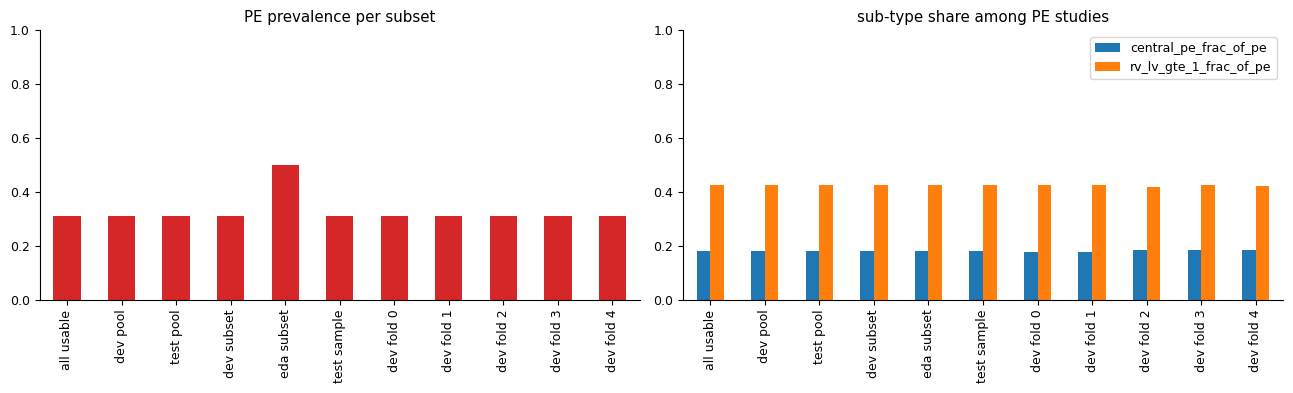

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
summary["pe_frac"].plot.bar(ax=axes[0], color=viz.COLOR_PE, title="PE prevalence per subset")
summary[["central_pe_frac_of_pe", "rv_lv_gte_1_frac_of_pe"]].plot.bar(ax=axes[1], title="sub-type share among PE studies")
for ax in axes:
    ax.set_ylim(0, 1); ax.set_xlabel("")
fig.tight_layout()
viz.save_fig(fig, FIG, NOTEBOOK, "class_balance_per_split");

## Save the split table

In [12]:
storage.atomic_write_parquet(split_table, cfg.splits_path)
print("saved", cfg.splits_path)
split_table.head()

saved /content/drive/MyDrive/rsna-pe/splits/splits.parquet


,study_uid,y,rv_lv_ratio_gte_1,rv_lv_ratio_lt_1,central_pe,leftsided_pe,rightsided_pe,chronic_pe,acute_and_chronic_pe,pool,in_test_sample,in_dev,in_eda,fold
0,0003b3d648eb,0,0,0,0,0,0,0,0,test,False,False,False,-1
1,000f7f114264,0,0,0,0,0,0,0,0,dev,False,False,False,-1
2,00102474a2db,0,0,0,0,0,0,0,0,dev,False,False,False,-1
3,0038fd5f09f5,0,0,0,0,0,0,0,0,dev,False,False,False,-1
4,0045f113e031,0,0,0,0,0,0,0,0,dev,False,True,False,2


## What we learned

    - The usable dataset is a few thousand studies with roughly a 30 % PE prevalence; the class imbalance is moderate, not extreme.
- A typical study has a couple of hundred slices and a PE study has a few dozen positive slices, but the range is huge (from a single slice to almost the whole scan).
- All zip members are deflate-compressed, so each DICOM must be inflated after its range request (about half the raw size travels over the network).
- The test pool is frozen here and must not be opened again until the last cell of the linear-probe notebook.
- (fill in after running) anything surprising in the split summary table.